# 🔭 Exploring the Galaxy Database
### EPS Research High-School Exploration Track — Ages 12-14

Scientists collected data on 438 real galaxies!
Let's explore this database and find out what kinds of galaxies are in it.

In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np

with open('rotation_curve_corpus_v7.json') as f:
    corpus = json.load(f)

galaxies = [g for g in corpus['galaxies']
            if g.get('vrot_max_kms')]

# Sort by max speed
fastest = sorted(galaxies, key=lambda x: float(x['vrot_max_kms']), reverse=True)

print("🏆 The 5 FASTEST spinning galaxies in our database:")
for g in fastest[:5]:
    print(f"  {g['galaxy']:<15}  {float(g['vrot_max_kms']):.0f} km/s  "
          f"({float(g['vrot_max_kms'])*3600:.0f} km/h!)")

print()
slowest = sorted(galaxies, key=lambda x: float(x['vrot_max_kms']))
print("🐢 The 5 SLOWEST spinning galaxies:")
for g in slowest[:5]:
    print(f"  {g['galaxy']:<15}  {float(g['vrot_max_kms']):.0f} km/s")

🏆 The 5 FASTEST spinning galaxies in our database:
  WALLABY_J133314-160715  362 km/s  (1301688 km/h!)
  WALLABY_J103702-273359  355 km/s  (1277352 km/h!)
  WALLABY_J130516-172641  318 km/s  (1146456 km/h!)
  WALLABY_J130415-102023  313 km/s  (1125576 km/h!)
  WALLABY_J132608-163111  296 km/s  (1065816 km/h!)

🐢 The 5 SLOWEST spinning galaxies:
  WALLABY_J124947+035042  17 km/s
  WALLABY_J130213-171416  22 km/s
  WALLABY_J125956-192430  25 km/s
  WALLABY_J133010-240841  27 km/s
  WALLABY_J131206+052832  32 km/s


/tmp/ipykernel_939791/3618334517.py:17: UserWarning: Glyph 127756 (\N{MILKY WAY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_939791/3618334517.py:18: UserWarning: Glyph 127756 (\N{MILKY WAY}) missing from font(s) DejaVu Sans.
  plt.savefig('hs_a_05_speed_distribution.png', dpi=150, bbox_inches='tight')
/home/david/jupyterlab/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127756 (\N{MILKY WAY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


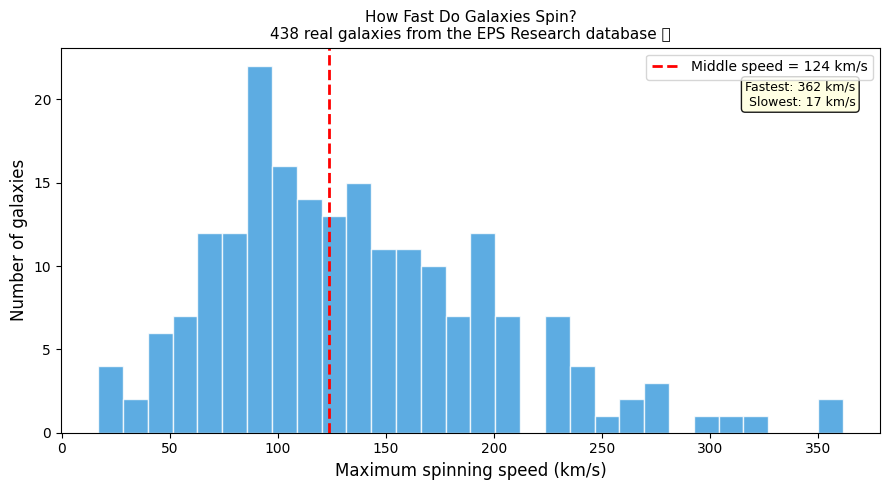

In [2]:
# Plot the distribution of galaxy speeds
speeds = [float(g['vrot_max_kms']) for g in galaxies]

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(speeds, bins=30, color='#3498db', alpha=0.8, edgecolor='white')
ax.axvline(np.median(speeds), color='red', linestyle='--', linewidth=2,
           label=f'Middle speed = {np.median(speeds):.0f} km/s')
ax.set_xlabel('Maximum spinning speed (km/s)', fontsize=12)
ax.set_ylabel('Number of galaxies', fontsize=12)
ax.set_title('How Fast Do Galaxies Spin?\n438 real galaxies from the EPS Research database 🌌',
             fontsize=11)
ax.legend(fontsize=10)
ax.text(0.97, 0.85,
        f'Fastest: {max(speeds):.0f} km/s\nSlowest: {min(speeds):.0f} km/s',
        transform=ax.transAxes, ha='right', fontsize=9,
        bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.9))
plt.tight_layout()
plt.savefig('hs_a_05_speed_distribution.png', dpi=150, bbox_inches='tight')
plt.show()